In [137]:
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema
from scipy.signal import find_peaks
from itertools import product
from tqdm import tqdm
import time
import numba as nb
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import talib as ta
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity

In [138]:
df=pd.read_csv('../EUR_USD_2020_M5.csv')

In [139]:
df.set_index('time',inplace=True)

In [140]:
df['STOCH']= ta.STOCH(df['h'], df['l'], df['c'], fastk_period=5, slowk_period=3, slowk_matype=0, slowd_period=3, slowd_matype=0)[1]

In [141]:
df_test=df.iloc[2000:2500].copy()

In [142]:
df_test['idx']=range(len(df_test))

In [143]:
def calc_low_points(low_vals):

    temp_min=low_vals[0]
    

    for i in range(len(low_vals)):

         if low_vals[i]<temp_min:

             temp_min=low_vals[i]


        

    if temp_min==low_vals[-2]:

       return low_vals[-2]

    else:

        return -101

In [144]:
def calc_high_points(high_vals):

    temp_max=high_vals[0]
    

    for i in range(len(high_vals)):

         if high_vals[i]>temp_max:

             temp_max=high_vals[i]


        

    if temp_max==high_vals[-2]:

       return high_vals[-2]

    else:

        return 101

In [145]:
def find_ll(stoch):


    temp_min=-101
   

    for i in range(len(stoch) - 2, -1, -1):
        if stoch[i]!=-101:
       
            if stoch[i]<stoch[-1]:
    
                temp_min=stoch[i]
                
                break

               
    
    return temp_min

In [146]:
def find_hh(stoch):

    temp_max=101

    for i in range(len(stoch) - 2, -1, -1):
        if stoch[i]!=101:
       
            if stoch[i]>stoch[-1]:
    
                temp_max=stoch[i]
                
                break

               
    
    return temp_max

In [147]:
def find_ll_idx(stoch):

    
    last_min_idx=0

    for i in range(len(stoch) - 2, -1, -1):
        if stoch[i]!=-101:
        
            if stoch[i]<stoch[-1]:
    
                
                last_min_idx=i-1
                break

               
    
    return last_min_idx

In [148]:
def find_hh_idx(stoch):

    
    last_max_idx=0

    for i in range(len(stoch) - 2, -1, -1):
        if stoch[i]!=101:
        
            if stoch[i]>stoch[-1]:
        
                
                last_max_idx=i-1
                break

               
    
    return last_max_idx

In [149]:
window=30

In [150]:
df_test['ll']=df_test['STOCH'].rolling(3).apply(calc_low_points, raw=True, engine='numba')

In [151]:
df_test['hh']=df_test['STOCH'].rolling(3).apply(calc_high_points, raw=True, engine='numba')

In [152]:
df_test['last_min']=df_test['ll'].rolling(window).apply(find_ll, raw=True, engine='numba')
df_test['last_max']=df_test['hh'].rolling(window).apply(find_hh, raw=True, engine='numba')

In [153]:
df_test[50:100]

,o,h,l,c,volume,complete,STOCH,idx,ll,hh,last_min,last_max
time,,,,,,,,,,,,
2020-01-13 02:30:00+00:00,1.11210,1.11210,1.11206,1.11210,12,True,41.260221,50,33.474427,101.000000,15.226337,101.000000
2020-01-13 02:35:00+00:00,1.11210,1.11222,1.11210,1.11220,31,True,54.901395,51,-101.000000,101.000000,-101.000000,101.000000
2020-01-13 02:40:00+00:00,1.11218,1.11234,1.11218,1.11233,75,True,73.708514,52,-101.000000,101.000000,-101.000000,101.000000
2020-01-13 02:45:00+00:00,1.11232,1.11234,1.11228,1.11232,33,True,85.392015,53,-101.000000,101.000000,-101.000000,101.000000
2020-01-13 02:50:00+00:00,1.11231,1.11246,1.11231,1.11244,36,True,92.710438,54,-101.000000,101.000000,-101.000000,101.000000
2020-01-13 02:55:00+00:00,1.11246,1.11262,1.11244,1.11258,51,True,93.921634,55,-101.000000,101.000000,-101.000000,101.000000
2020-01-13 03:00:00+00:00,1.11260,1.11274,1.11254,1.11270,91,True,93.906279,56,-101.000000,93.921634,-101.000000,101.000000
2020-01-13 03:05:00+00:00,1.11269,1.11286,1.11269,1.11284,49,True,93.560692,57,-101.000000,101.000000,-101.000000,101.000000
2020-01-13 03:10:00+00:00,1.11286,1.11286,1.11280,1.11285,31,True,94.385787,58,93.560692,101.000000,33.474427,101.000000


In [154]:
df_test['prev_min_idx']=df_test['ll'].rolling(window).apply(find_ll_idx, raw=True, engine='numba')+df_test.idx-window+1
df_test['prev_max_idx']=df_test['hh'].rolling(window).apply(find_hh_idx, raw=True, engine='numba')+df_test.idx-window+1

In [155]:
df_test[50:100]

,o,h,l,c,volume,complete,STOCH,idx,ll,hh,last_min,last_max,prev_min_idx,prev_max_idx
time,,,,,,,,,,,,,,
2020-01-13 02:30:00+00:00,1.11210,1.11210,1.11206,1.11210,12,True,41.260221,50,33.474427,101.000000,15.226337,101.000000,28.0,21.0
2020-01-13 02:35:00+00:00,1.11210,1.11222,1.11210,1.11220,31,True,54.901395,51,-101.000000,101.000000,-101.000000,101.000000,22.0,22.0
2020-01-13 02:40:00+00:00,1.11218,1.11234,1.11218,1.11233,75,True,73.708514,52,-101.000000,101.000000,-101.000000,101.000000,23.0,23.0
2020-01-13 02:45:00+00:00,1.11232,1.11234,1.11228,1.11232,33,True,85.392015,53,-101.000000,101.000000,-101.000000,101.000000,24.0,24.0
2020-01-13 02:50:00+00:00,1.11231,1.11246,1.11231,1.11244,36,True,92.710438,54,-101.000000,101.000000,-101.000000,101.000000,25.0,25.0
2020-01-13 02:55:00+00:00,1.11246,1.11262,1.11244,1.11258,51,True,93.921634,55,-101.000000,101.000000,-101.000000,101.000000,26.0,26.0
2020-01-13 03:00:00+00:00,1.11260,1.11274,1.11254,1.11270,91,True,93.906279,56,-101.000000,93.921634,-101.000000,101.000000,27.0,27.0
2020-01-13 03:05:00+00:00,1.11269,1.11286,1.11269,1.11284,49,True,93.560692,57,-101.000000,101.000000,-101.000000,101.000000,28.0,28.0
2020-01-13 03:10:00+00:00,1.11286,1.11286,1.11280,1.11285,31,True,94.385787,58,93.560692,101.000000,33.474427,101.000000,49.0,29.0


In [156]:
df_test['last_min_idx']=np.where((df_test['ll']!=-101)&(df_test['last_min']!=-101)&(df_test['ll'].notna()), df_test['idx'].shift(),0)
df_test['last_max_idx']=np.where((df_test['hh']!=101)&(df_test['last_max']!=101)&(df_test['hh'].notna()), df_test['idx'].shift(),0)

In [157]:
df_test['last_min_price']=np.where((df_test['ll']!=-101)&(df_test['last_min']!=-101)&(df_test['ll'].notna()), df_test['l'].shift(),0)
df_test['last_max_price']=np.where((df_test['hh']!=101)&(df_test['last_max']!=101)&(df_test['hh'].notna()), df_test['h'].shift(),0)

In [158]:
prev_min_prices_idx=np.array(df_test['prev_min_idx'])
prev_max_prices_idx=np.array(df_test['prev_max_idx'])
prev_min_prices=np.array(df_test['l'].iloc[np.nan_to_num(prev_min_prices_idx)])
prev_max_prices=np.array(df_test['h'].iloc[np.nan_to_num(prev_max_prices_idx)])
df_test['prev_min_prices']=prev_min_prices
df_test['prev_max_prices']=prev_max_prices

In [159]:
df_test[50:100].loc[:,['idx','h','STOCH','hh','last_max','last_max_idx','prev_max_idx','last_max_price','prev_max_prices']]

,idx,h,STOCH,hh,last_max,last_max_idx,prev_max_idx,last_max_price,prev_max_prices
time,,,,,,,,,
2020-01-13 02:30:00+00:00,50,1.11210,41.260221,101.000000,101.000000,0.0,21.0,0.00000,1.11179
2020-01-13 02:35:00+00:00,51,1.11222,54.901395,101.000000,101.000000,0.0,22.0,0.00000,1.11184
2020-01-13 02:40:00+00:00,52,1.11234,73.708514,101.000000,101.000000,0.0,23.0,0.00000,1.11188
2020-01-13 02:45:00+00:00,53,1.11234,85.392015,101.000000,101.000000,0.0,24.0,0.00000,1.11180
2020-01-13 02:50:00+00:00,54,1.11246,92.710438,101.000000,101.000000,0.0,25.0,0.00000,1.11172
2020-01-13 02:55:00+00:00,55,1.11262,93.921634,101.000000,101.000000,0.0,26.0,0.00000,1.11167
2020-01-13 03:00:00+00:00,56,1.11274,93.906279,93.921634,101.000000,0.0,27.0,0.00000,1.11170
2020-01-13 03:05:00+00:00,57,1.11286,93.560692,101.000000,101.000000,0.0,28.0,0.00000,1.11176
2020-01-13 03:10:00+00:00,58,1.11286,94.385787,101.000000,101.000000,0.0,29.0,0.00000,1.11184


In [160]:
df_test[50:100].loc[:,['idx','l','STOCH','ll','last_min','last_min_idx','prev_min_idx','last_min_price','prev_min_prices']]

,idx,l,STOCH,ll,last_min,last_min_idx,prev_min_idx,last_min_price,prev_min_prices
time,,,,,,,,,
2020-01-13 02:30:00+00:00,50,1.11206,41.260221,33.474427,15.226337,49.0,28.0,1.11208,1.11168
2020-01-13 02:35:00+00:00,51,1.11210,54.901395,-101.000000,-101.000000,0.0,22.0,0.00000,1.11177
2020-01-13 02:40:00+00:00,52,1.11218,73.708514,-101.000000,-101.000000,0.0,23.0,0.00000,1.11178
2020-01-13 02:45:00+00:00,53,1.11228,85.392015,-101.000000,-101.000000,0.0,24.0,0.00000,1.11162
2020-01-13 02:50:00+00:00,54,1.11231,92.710438,-101.000000,-101.000000,0.0,25.0,0.00000,1.11162
2020-01-13 02:55:00+00:00,55,1.11244,93.921634,-101.000000,-101.000000,0.0,26.0,0.00000,1.11162
2020-01-13 03:00:00+00:00,56,1.11254,93.906279,-101.000000,-101.000000,0.0,27.0,0.00000,1.11164
2020-01-13 03:05:00+00:00,57,1.11269,93.560692,-101.000000,-101.000000,0.0,28.0,0.00000,1.11168
2020-01-13 03:10:00+00:00,58,1.11280,94.385787,93.560692,33.474427,57.0,49.0,1.11269,1.11208


In [161]:
cond_buy_check=(df_test['ll']!=-101)&(df_test['last_min']!=-101)&(df_test['prev_min_idx'].notna())
cond_buy_price=(df_test['last_min_price']!=0)&(df_test['prev_min_prices']>df_test['last_min_price'])
cond_sell_check=(df_test['hh']!=101)&(df_test['last_max']!=101)&(df_test['prev_max_idx'].notna())
cond_sell_price=(df_test['last_max_price']!=0)&(df_test['prev_max_prices']<df_test['last_max_price'])

In [162]:
df_test['div_pos']=np.nan
df_test['div_pos']=np.where(cond_buy_check&cond_buy_price,1,df_test['div_pos'])
df_test['div_pos']=np.where(cond_sell_check&cond_sell_price,-1,df_test['div_pos'])

In [163]:
df_test['div_pos'].value_counts()

div_pos
 1.0    19
-1.0    14
Name: count, dtype: int64

In [164]:
df_plot=df_test.copy()

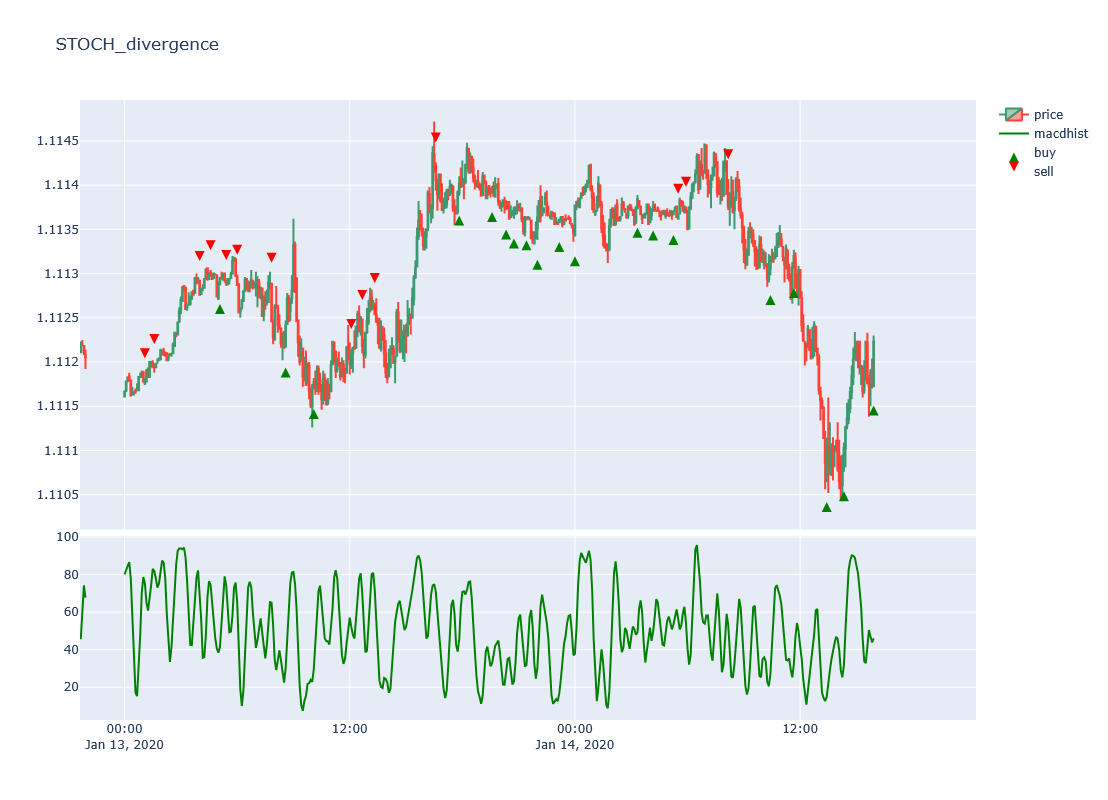

In [165]:
figure = make_subplots(rows=2, cols=1, row_heights=[0.7,0.3], shared_xaxes=True,vertical_spacing=0.01)
figure.update_layout(height=800, width=1200, title_text='STOCH_divergence')

pos_col='div_pos'

y_color_buy=df_plot[df_plot[pos_col]==1]['l']*0.9998
y_color_buy_index=df_plot[df_plot[pos_col]==1].index
y_color_sell=df_plot[df_plot[pos_col]==-1]['h']*1.0002
y_color_sell_index=df_plot[df_plot[pos_col]==-1].index

#y_color_sell=df_plot[df_plot['pos_ch_bear']==-1]['h']*1.0002
#y_color_sell_index=df_plot[df_plot['pos_ch_bear']==-1].index
#y_color_buy=df_plot[df_plot['pos_ch_bull']==1]['l']*0.9998
#y_color_buy_index=df_plot[df_plot['pos_ch_bull']==1].index


figure.add_trace(go.Candlestick(x=df_plot.index,
                                open=df_plot['o'],
                                high=df_plot['h'],
                                low=df_plot['l'],
                                close=df_plot['c'],
                                name='price'), row=1, col=1)

figure.add_trace(go.Scatter(x=df_plot.index,y=df_plot['STOCH'],mode='lines',line_color='green',name='macdhist'),col=1,row=2)
#figure.add_trace(go.Scatter(x=df_plot.index,y=df_plot['MACD_high'],mode='lines',line_color='red',name='macdhist'),col=1,row=2)
figure.add_trace(go.Scatter(x=y_color_buy_index, y=y_color_buy, mode='markers', marker_symbol='arrow-up', marker_color='green', name='buy', marker_size=10), col=1, row=1)
figure.add_trace(go.Scatter(x=y_color_sell_index, y=y_color_sell, mode='markers', marker_symbol='arrow-down', marker_color='red', name='sell', marker_size=10), col=1, row=1)
#for i in idxs:
    

    #figure.add_trace(go.Scatter(x=df_plot.loc[i].index,y=df_plot['RSI_low'].loc[i],mode='lines',line_color='red',name='macdhist'),col=1,row=2)

    

figure.update_layout(xaxis_rangeslider_visible=False)
figure.update_xaxes(
        rangebreaks=[
            dict(bounds=["sat", "mon"])]
    )
figure.show()

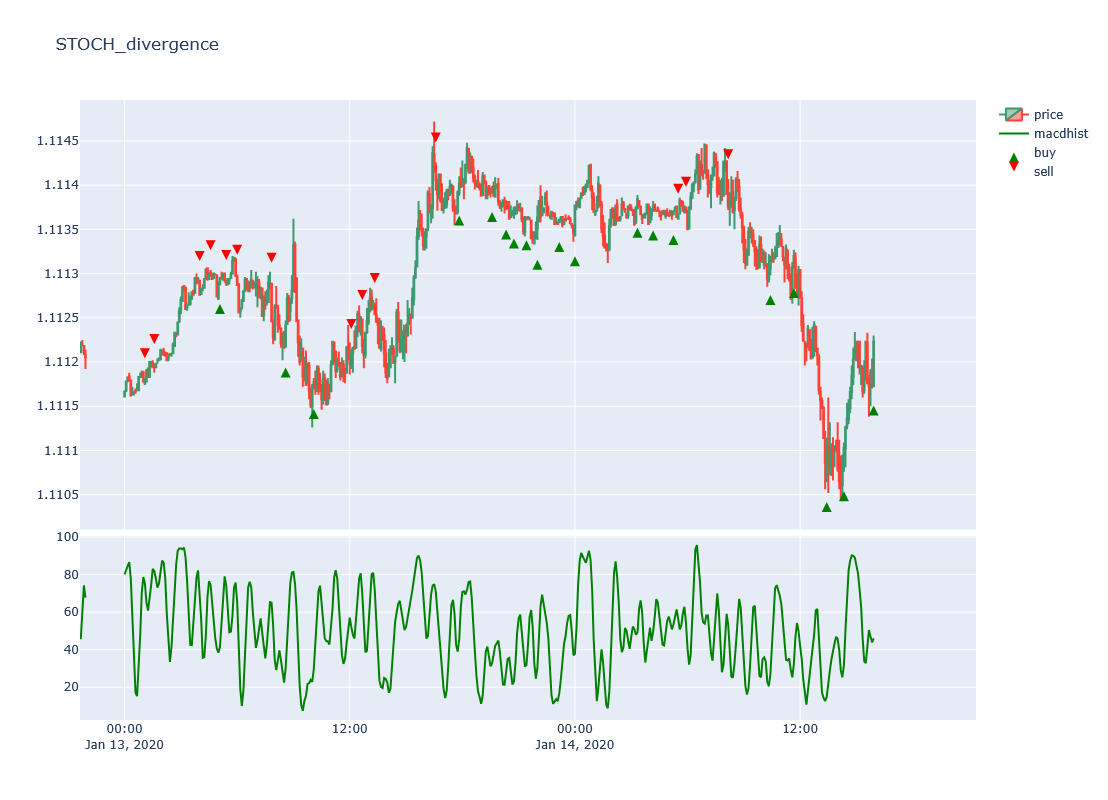

In [166]:
figure = make_subplots(rows=2, cols=1, row_heights=[0.7,0.3], shared_xaxes=True,vertical_spacing=0.01)
figure.update_layout(height=800, width=1200, title_text='STOCH_divergence')

pos_col='div_pos'

y_color_buy=df_plot[df_plot[pos_col]==1]['l']*0.9998
y_color_buy_index=df_plot[df_plot[pos_col]==1].index
y_color_sell=df_plot[df_plot[pos_col]==-1]['h']*1.0002
y_color_sell_index=df_plot[df_plot[pos_col]==-1].index

#y_color_sell=df_plot[df_plot['pos_ch_bear']==-1]['h']*1.0002
#y_color_sell_index=df_plot[df_plot['pos_ch_bear']==-1].index
#y_color_buy=df_plot[df_plot['pos_ch_bull']==1]['l']*0.9998
#y_color_buy_index=df_plot[df_plot['pos_ch_bull']==1].index


figure.add_trace(go.Candlestick(x=df_plot.index,
                                open=df_plot['o'],
                                high=df_plot['h'],
                                low=df_plot['l'],
                                close=df_plot['c'],
                                name='price'), row=1, col=1)

figure.add_trace(go.Scatter(x=df_plot.index,y=df_plot['STOCH'],mode='lines',line_color='green',name='macdhist'),col=1,row=2)
#figure.add_trace(go.Scatter(x=df_plot.index,y=df_plot['MACD_high'],mode='lines',line_color='red',name='macdhist'),col=1,row=2)
figure.add_trace(go.Scatter(x=y_color_buy_index, y=y_color_buy, mode='markers', marker_symbol='arrow-up', marker_color='green', name='buy', marker_size=10), col=1, row=1)
figure.add_trace(go.Scatter(x=y_color_sell_index, y=y_color_sell, mode='markers', marker_symbol='arrow-down', marker_color='red', name='sell', marker_size=10), col=1, row=1)
#for i in idxs:
    

    #figure.add_trace(go.Scatter(x=df_plot.loc[i].index,y=df_plot['RSI_low'].loc[i],mode='lines',line_color='red',name='macdhist'),col=1,row=2)

    

figure.update_layout(xaxis_rangeslider_visible=False)
figure.update_xaxes(
        rangebreaks=[
            dict(bounds=["sat", "mon"])]
    )
figure.show()